In [ ]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.

import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(2500, 50) | n_z_dims = 3 | shift_sigma = 0.1


AnnData object with n_obs × n_vars = 2500 × 50
    obs: 'latent_t', 'shift', 'batch', 'latent_z0', 'latent_z1', 'latent_z2'
    uns: 'n_z_dims', 'shift_matrix', 'shift_sigma'
    layers: 'counts'

In [ ]:
def my_reconstruction_for_run(date, shift_sigma, seed, model, decipher_seed):
    folder = "../Data/Simulated Data/Simulated Adata/reconstruction_eval"
    ADATA_PATH = os.path.join(
            folder, date, f"untrained/sigma{shift_sigma}_seed{seed}.h5ad"
        )
    adata = sc.read_h5ad(ADATA_PATH)
    dim_z = int(adata.uns["n_z_dims"])
    print(adata.shape, "| n_z_dims =", dim_z, "| shift_sigma =", float(adata.uns["shift_sigma"]))

    if model == "decipher_vz":
        import decipher_vz as dc
        from decipher_vz.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'decipher_vz'
    elif model == "decipher_vz2":
        import decipher_vz2 as dc
        from decipher_vz2.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'decipher_vz2'
    elif model == "decipher_mf":
        import decipher_mf as dc
        from decipher_mf.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'decipher_mf'   # fixed: your rho version has this as 'decipher_vz2', looks like a copy-paste typo
    elif model == "base decipher":
        import decipher as dc
        from decipher.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'base decipher'

    config = DecipherConfig(learning_rate=1e-3, seed=decipher_seed, dim_z=dim_z)
    decipher, _ = dc.tl.decipher_train(
        adata, config,
        plot_kwargs={"color": "batch", "title": f"sigma={shift_sigma}"},
    )

    # Reconstruction diagnostic
    result = dc.tl.reconstruction_r2_log1p(decipher, adata)
    fig, axes = dc.pl.reconstruction_r2_log1p(decipher, adata, figsize=(21,5))  # uses cache from tl call
    for ax in axes:
        ax.title.set_fontsize(10)
        ax.xaxis.label.set_fontsize(9)
        ax.yaxis.label.set_fontsize(9)
        ax.tick_params(labelsize=8)
        if ax.get_legend() is not None:
            for text in ax.get_legend().get_texts():
                text.set_fontsize(8)
    fig.suptitle(
        f"{model_tag} | sigma={shift_sigma} | decipher seed={decipher_seed}",
        y=1.02, fontsize=11,
    )

    import numpy as np
    r2_overall = result["r2_overall"]
    r2_per_gene_median = float(np.nanmedian(result["r2_per_gene"]))
    
    # Save the TRAINED adata. It has decipher_z, decipher_v in adata.obsm,
    trained_dir = os.path.join(folder, date, "trained")
    os.makedirs(trained_dir, exist_ok=True)
    trained_h5ad_path = os.path.join(
            trained_dir, f"sigma{shift_sigma}_seed{seed}_{model_tag}_decipherseed_{decipher_seed}.h5ad"
        )
    adata.write(trained_h5ad_path)

    return r2_overall, r2_per_gene_median, decipher, adata

Epoch 55 (batch 23/23) | | train elbo: 37.87 (last epoch: 37.61) | val ll: 47.57:   6%|▌         | 55/1000 [00:40<11:28,  1.37it/s]2026-08-04 00:25:14,862 | INFO : Early stopping has been triggered.
2026-08-04 00:25:14,866 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-08-04 00:25:14,867 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-08-04 00:25:14,868 | INFO : Saving decipher model with run_id 2026-08-04-00-25-14-lean-brass-burrito.


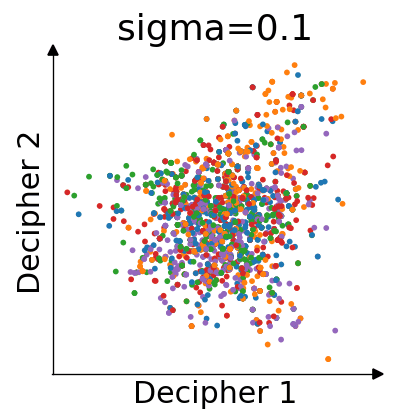

overall R^2: 0.717
median per-gene R^2: 0.272


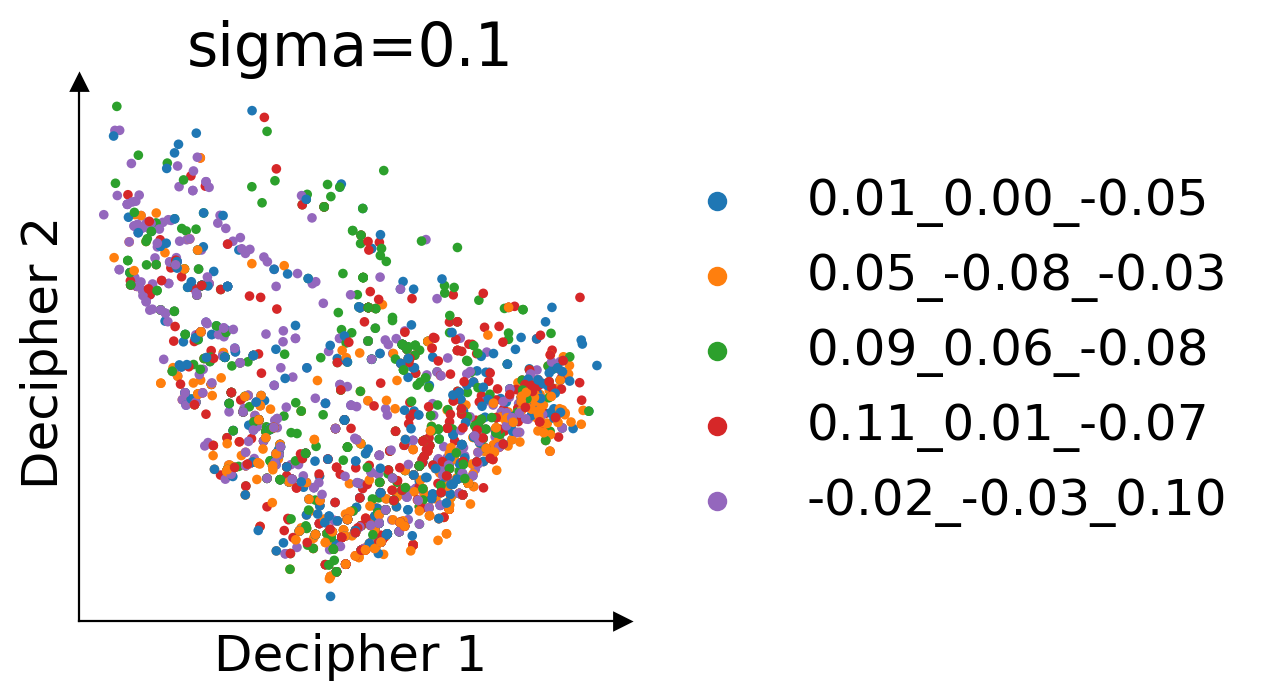

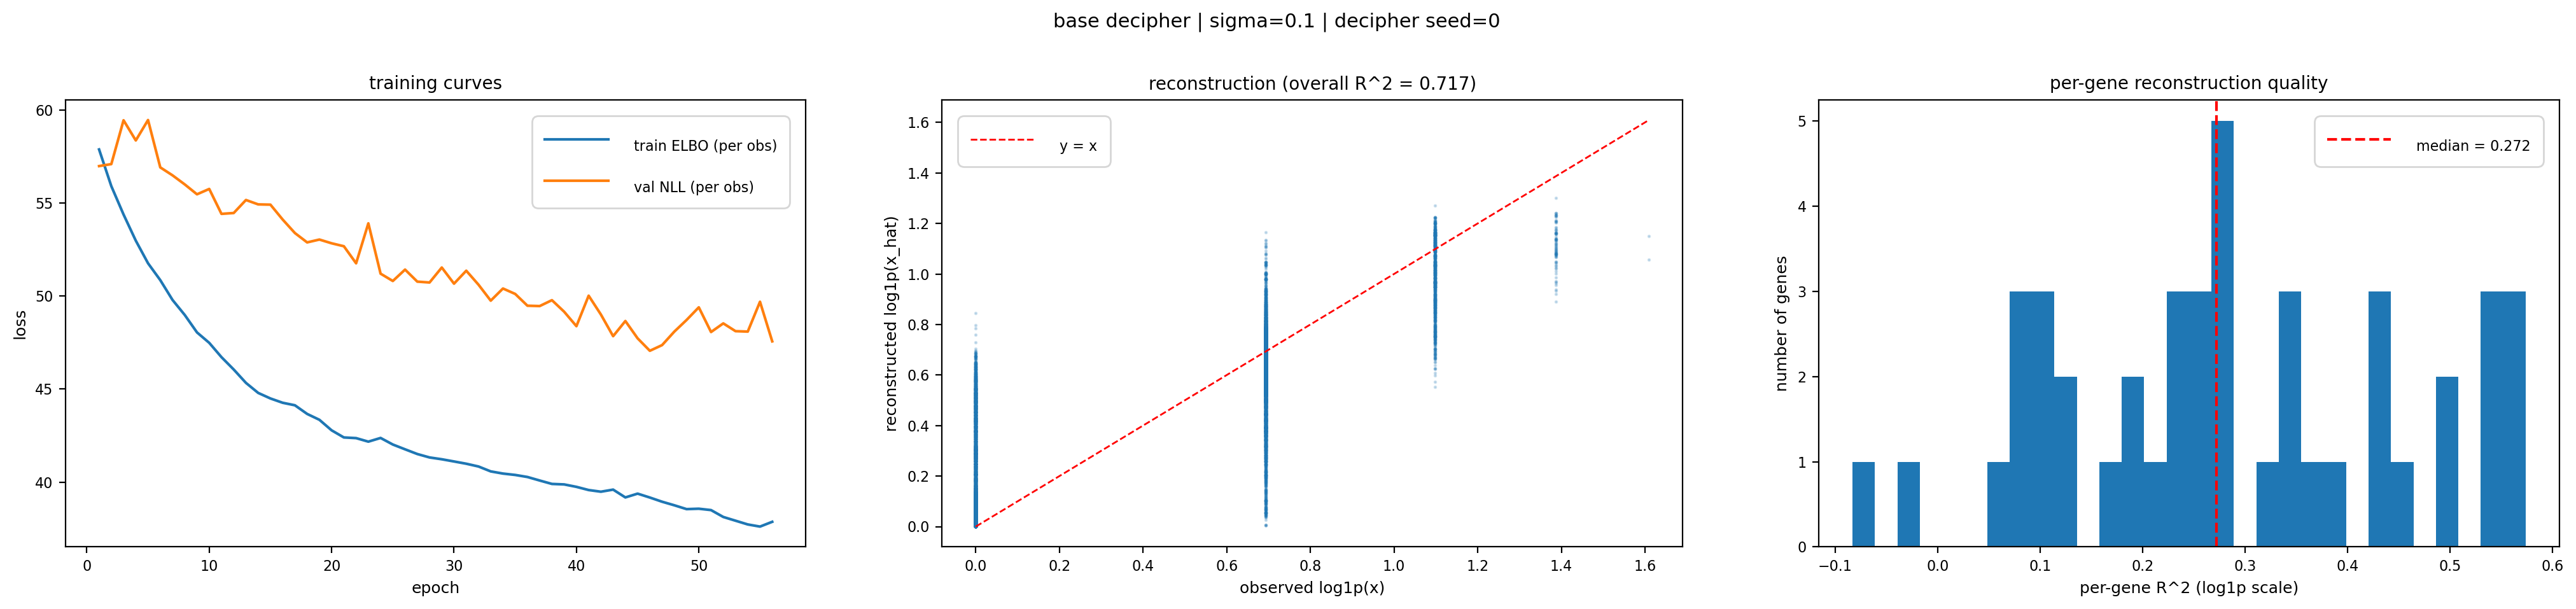

In [15]:
r2_overall, r2_per_gene_med, base_decipher, trained_adata_base = my_reconstruction_for_run(
    date="0804", shift_sigma=0.1, seed=0, model="base decipher", decipher_seed=0
)
print(f"overall R^2: {r2_overall:.3f}")
print(f"median per-gene R^2: {r2_per_gene_med:.3f}")

In [19]:
def my_reconstruction_all_models(date, shift_sigma, seed, n_samples, n_genes, decipher_seed):
    """Train all four decipher variants on the same simulated adata and return a
    single 4x3 reconstruction diagnostic figure (one row per model).

    Loads adata from:
      ../Data/Simulated Data/Simulated Adata/reconstruction_eval/{date}/untrained/
        sigma{shift_sigma}_seed{seed}.h5ad

    Writes per-model trained adata to:
      ../Data/Simulated Data/Simulated Adata/reconstruction_eval/{date}/trained/{model_tag}/
        sigma{shift_sigma}_seed{seed}_{model_tag}_decipherseed_{decipher_seed}.h5ad

    Writes summary CSV to:
      ../Data/Simulated Data/Simulated Adata/reconstruction_eval/{date}/
        reconstruction_summary_sigma{shift_sigma}_seed{seed}_decipherseed_{decipher_seed}.csv

    Parameters
    ----------
    date : str
        Date subfolder under reconstruction_eval, e.g. "2025-08-04".
    shift_sigma : float
        Batch shift magnitude.
    seed : int
        Simulation seed used to generate the untrained adata.
    decipher_seed : int
        Seed for DecipherConfig, shared across all four models.

    Returns
    -------
    fig : matplotlib.figure.Figure
        4 rows (one per model) x 3 cols.
    summary_df : pandas.DataFrame
        One row per model.
    trained : dict
        Keys are model_tag; values are (decipher, adata_copy) tuples.
    """
    import os
    import numpy as np
    import pandas as pd
    import scanpy as sc
    import matplotlib.pyplot as plt

    folder = "../Data/Simulated Data/Simulated Adata/reconstruction_eval"
    ADATA_PATH = os.path.join(
        folder, date, f"untrained/sigma{shift_sigma}_seed{seed}_{n_samples}_{n_genes}.h5ad"
    )
    adata = sc.read_h5ad(ADATA_PATH)
    dim_z = int(adata.uns["n_z_dims"])
    print(adata.shape, "| n_z_dims =", dim_z,
          "| shift_sigma =", float(adata.uns["shift_sigma"]))

    def _load_pkg(model_tag):
        if model_tag == "base_decipher":
            import decipher as dc
            from decipher.tools._decipher import DecipherConfig
        elif model_tag == "decipher_vz":
            import decipher_vz as dc
            from decipher_vz.tools._decipher import DecipherConfig
        elif model_tag == "decipher_vz2":
            import decipher_vz2 as dc
            from decipher_vz2.tools._decipher import DecipherConfig
        elif model_tag == "decipher_mf":
            import decipher_mf as dc
            from decipher_mf.tools._decipher import DecipherConfig
        else:
            raise ValueError(f"Unknown model_tag: {model_tag}")
        return dc, DecipherConfig

    model_tags = ["base_decipher", "decipher_vz", "decipher_vz2", "decipher_mf"]

    results = {}
    trained = {}
    summary_rows = []

    for model_tag in model_tags:
        dc, DecipherConfig = _load_pkg(model_tag)
        adata_copy = adata.copy()

        config = DecipherConfig(learning_rate=1e-3, seed=decipher_seed, dim_z=dim_z)
        decipher, _ = dc.tl.decipher_train(
            adata_copy, config,
            plot_kwargs={"color": "batch", "title": f"{model_tag} | sigma={shift_sigma}"},
        )

        result = dc.tl.reconstruction_r2_log1p(decipher, adata_copy)
        results[model_tag] = result
        trained[model_tag] = (decipher, adata_copy)

        summary_rows.append({
            "date": date,
            "shift_sigma": shift_sigma,
            "seed": seed,
            "decipher_seed": decipher_seed,
            "model_tag": model_tag,
            "r2_overall": result["r2_overall"],
            "r2_per_gene_median": float(np.nanmedian(result["r2_per_gene"])),
        })

        # Save trained adata
        trained_dir = os.path.join(folder, date, "trained", model_tag)
        os.makedirs(trained_dir, exist_ok=True)
        trained_h5ad_path = os.path.join(
            trained_dir,
            f"sigma{shift_sigma}_seed{seed}_{model_tag}_decipherseed_{decipher_seed}.h5ad",
        )
        adata_copy.write(trained_h5ad_path)

    # Summary CSV
    summary_df = pd.DataFrame(summary_rows)
    summary_csv_path = os.path.join(
        folder, date,
        f"reconstruction_summary_sigma{shift_sigma}_seed{seed}_decipherseed_{decipher_seed}.csv",
    )
    summary_df.to_csv(summary_csv_path, index=False)

    # Build the 4x3 figure
    n_scatter_points = 20_000
    scatter_seed = 0
    n_hist_bins = 30

    fig, axes = plt.subplots(4, 3, figsize=(15, 16))

    for row_idx, model_tag in enumerate(model_tags):
        result = results[model_tag]
        decipher, _ = trained[model_tag]

        # (col 0) Loss curves
        ax = axes[row_idx, 0]
        train_losses = getattr(decipher, "train_losses_", [])
        val_losses = getattr(decipher, "val_losses_", [])
        if train_losses:
            ax.plot(np.arange(1, len(train_losses) + 1), train_losses,
                    label="train ELBO")
        if val_losses:
            ax.plot(np.arange(1, len(val_losses) + 1), val_losses,
                    label="val NLL")
        ax.set_xlabel("epoch")
        ax.set_ylabel(f"{model_tag}\nloss")
        if row_idx == 0:
            ax.set_title("training curves")
        if train_losses or val_losses:
            ax.legend(fontsize=8)

        # (col 1) Reconstruction scatter
        ax = axes[row_idx, 1]
        x_log = result["x_log"]
        x_hat_log = result["x_hat_log"]
        flat_x = x_log.ravel()
        flat_xhat = x_hat_log.ravel()
        rng = np.random.default_rng(scatter_seed)
        idx = rng.choice(
            flat_x.size, size=min(n_scatter_points, flat_x.size), replace=False,
        )
        ax.scatter(flat_x[idx], flat_xhat[idx], s=1, alpha=0.2)
        lo = float(min(flat_x[idx].min(), flat_xhat[idx].min()))
        hi = float(max(flat_x[idx].max(), flat_xhat[idx].max()))
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
        ax.set_xlabel("observed log1p(x)")
        ax.set_ylabel("reconstructed log1p(x_hat)")
        if row_idx == 0:
            ax.set_title("reconstruction scatter")
        ax.text(
            0.05, 0.95, f"R² = {result['r2_overall']:.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )

        # (col 2) Per-gene R^2 histogram
        ax = axes[row_idx, 2]
        r2_per_gene = result["r2_per_gene"]
        valid = r2_per_gene[~np.isnan(r2_per_gene)]
        ax.hist(valid, bins=n_hist_bins)
        median_r2 = float(np.nanmedian(r2_per_gene))
        ax.axvline(
            median_r2, color="r", linestyle="--",
            label=f"median = {median_r2:.3f}",
        )
        ax.set_xlabel("per-gene R² (log1p)")
        ax.set_ylabel("number of genes")
        if row_idx == 0:
            ax.set_title("per-gene reconstruction quality")
        ax.legend(fontsize=8)

    fig.suptitle(
        f"sigma={shift_sigma} | seed={seed} | decipher seed={decipher_seed}",
        y=0.995, fontsize=12,
    )
    fig.tight_layout()

    return fig, summary_df, trained

Epoch 52 (batch 23/23) | | train elbo: 40.23 (last epoch: 40.38) | val ll: 42.41:   5%|▌         | 52/1000 [00:39<11:54,  1.33it/s]2026-08-04 00:38:35,247 | INFO : Early stopping has been triggered.
2026-08-04 00:38:35,252 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-08-04 00:38:35,252 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-08-04 00:38:35,253 | INFO : Saving decipher model with run_id 2026-08-04-00-38-35-acyclic-seething-burger.


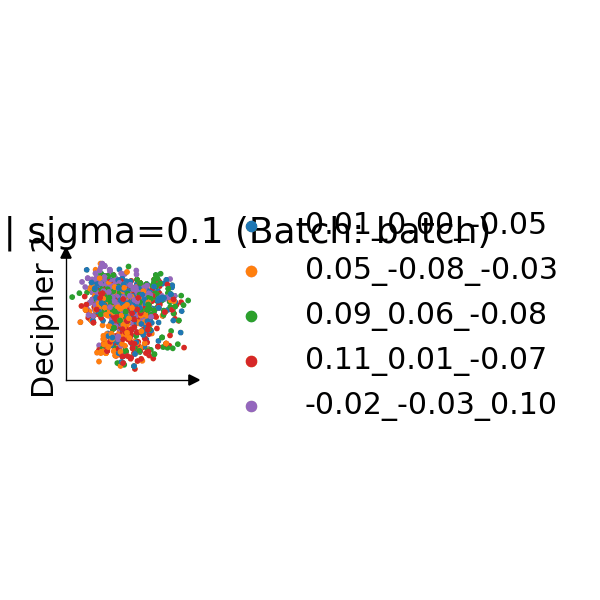

   date  shift_sigma  seed  decipher_seed      model_tag  r2_overall  \
0  0804          0.1     0              0  base_decipher    0.717411   
1  0804          0.1     0              0    decipher_vz    0.710415   
2  0804          0.1     0              0   decipher_vz2    0.788310   
3  0804          0.1     0              0    decipher_mf    0.734808   

   r2_per_gene_median  
0            0.271845  
1            0.225030  
2            0.444062  
3            0.269473  


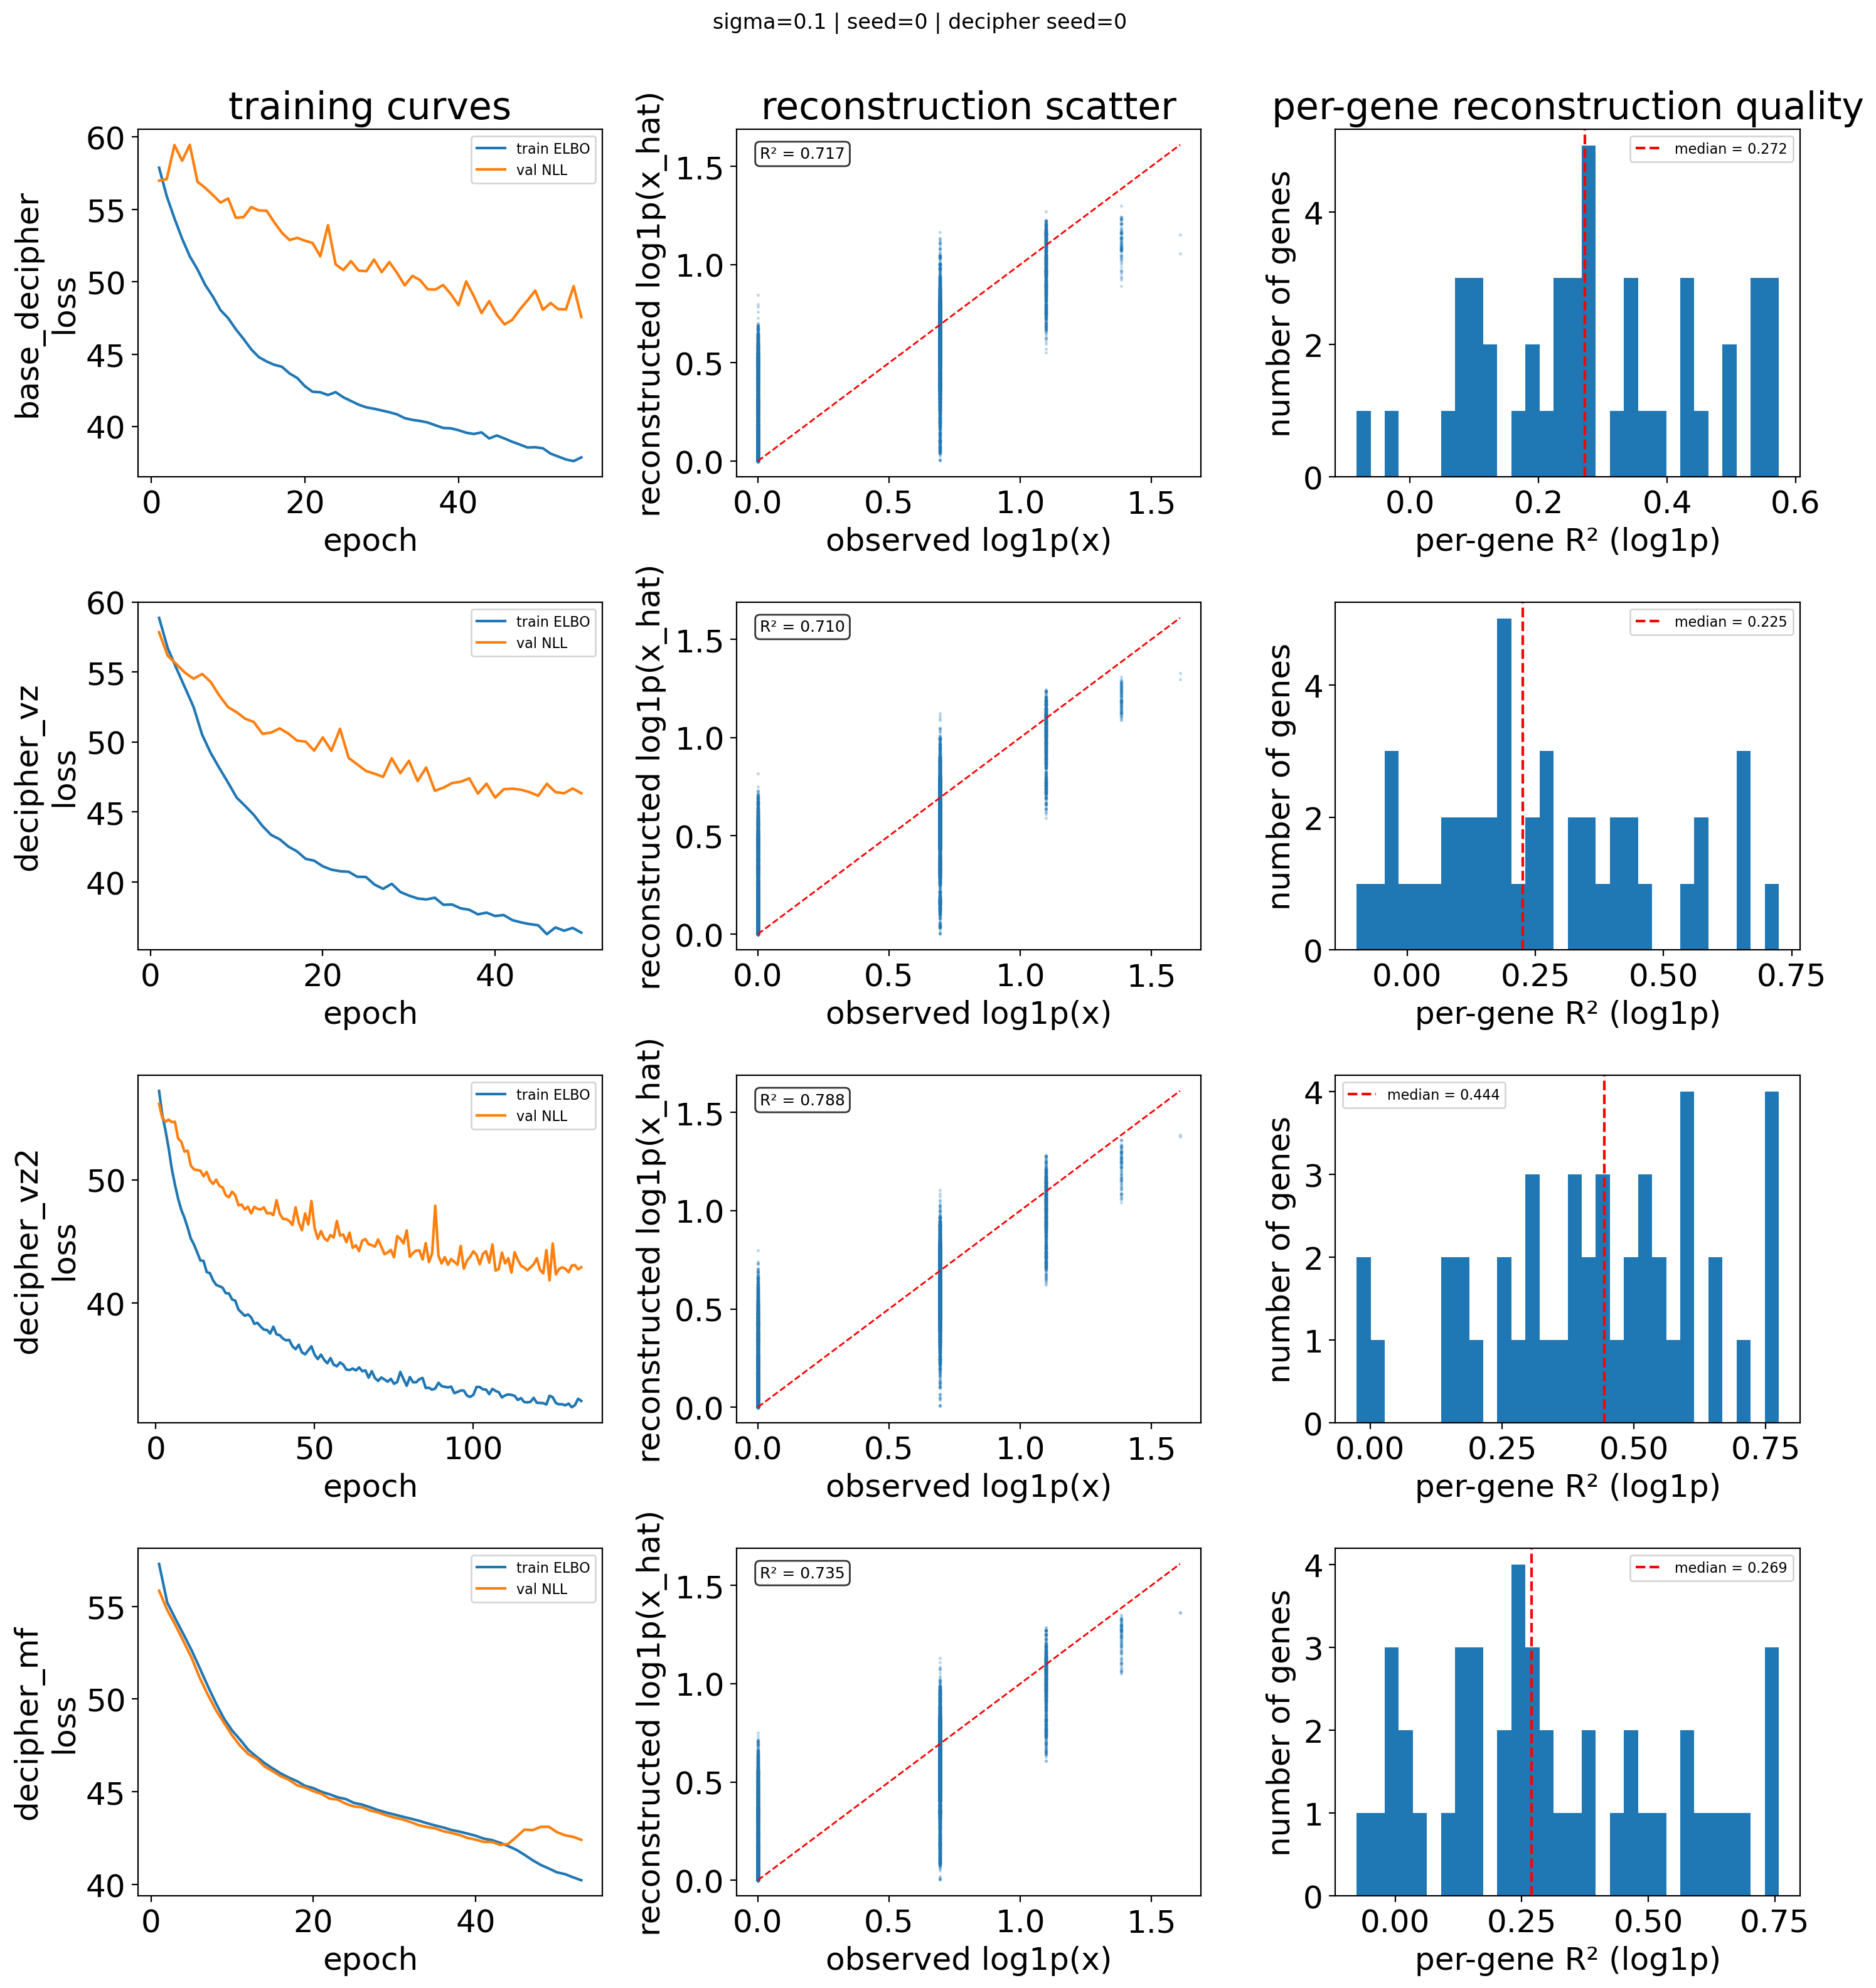

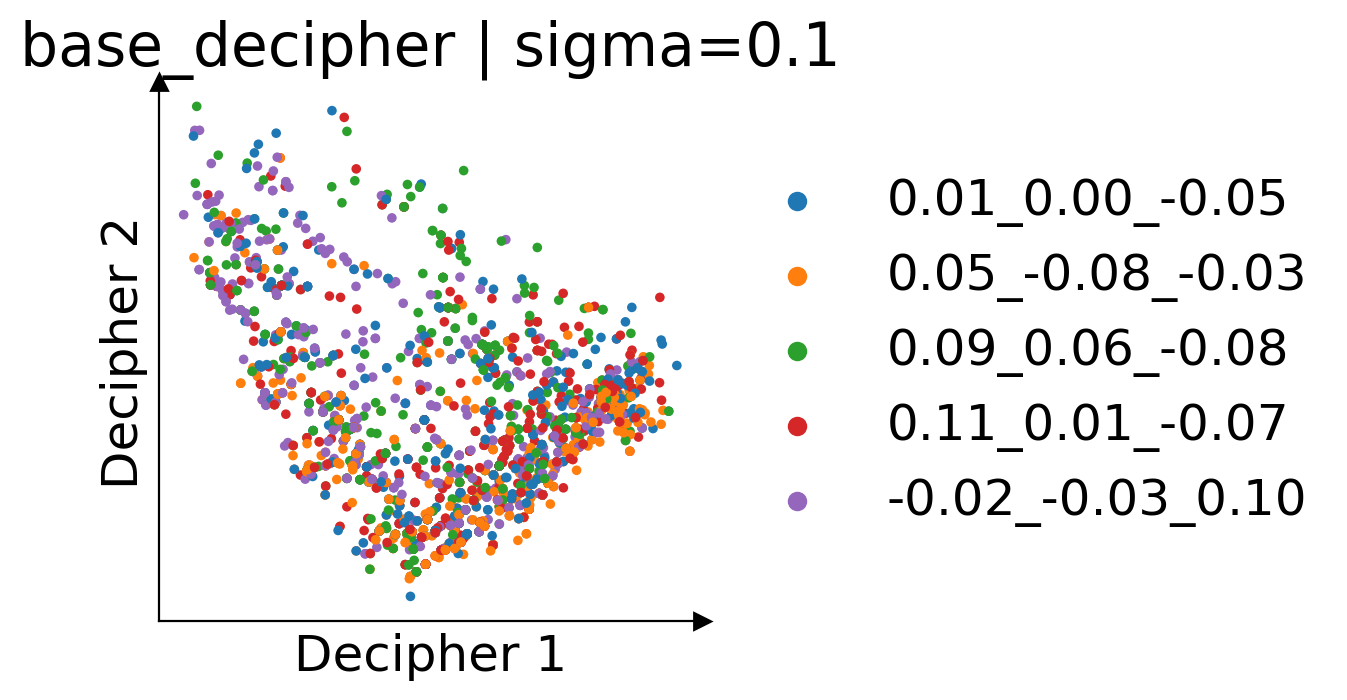

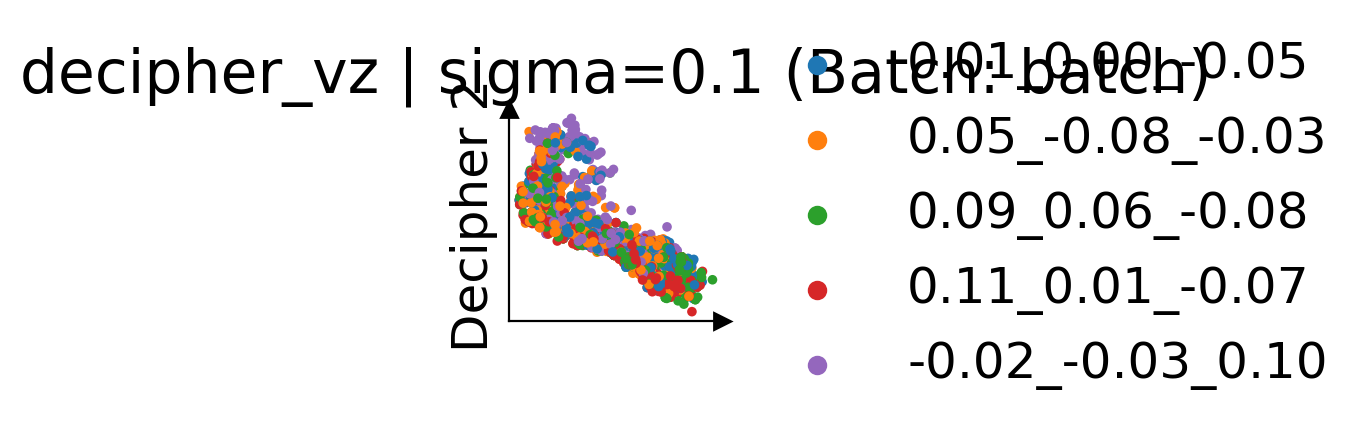

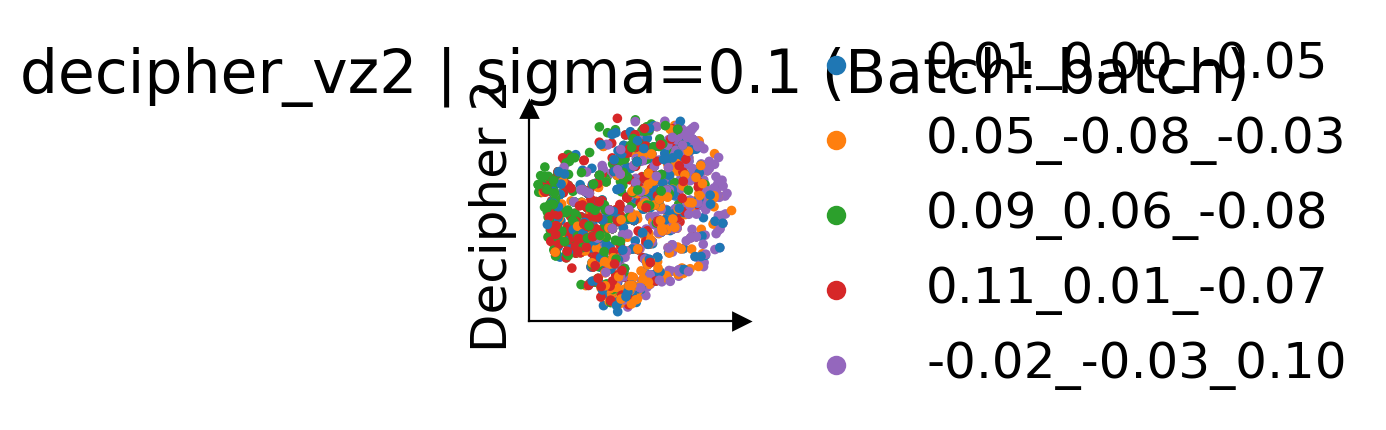

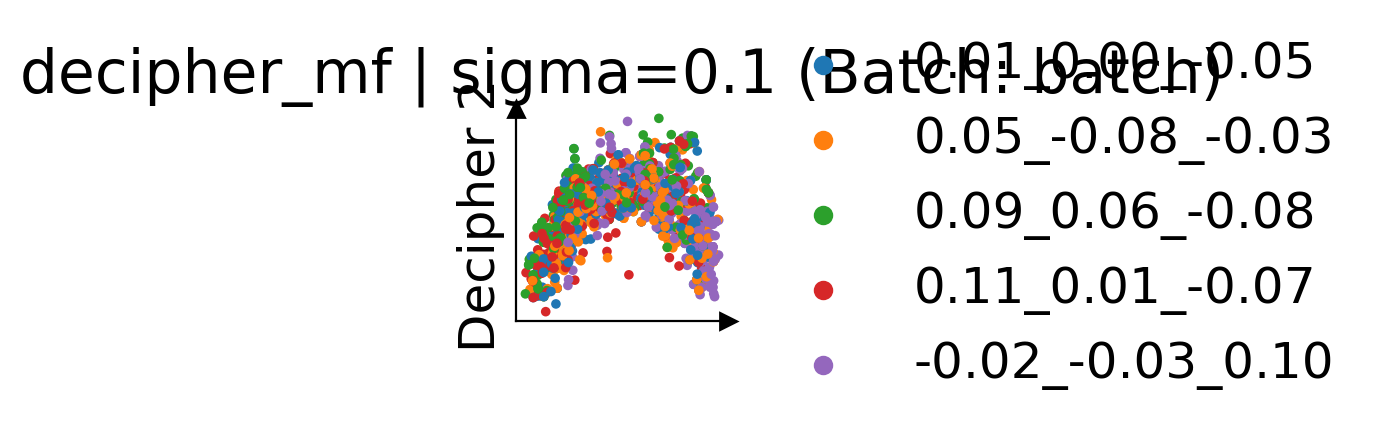

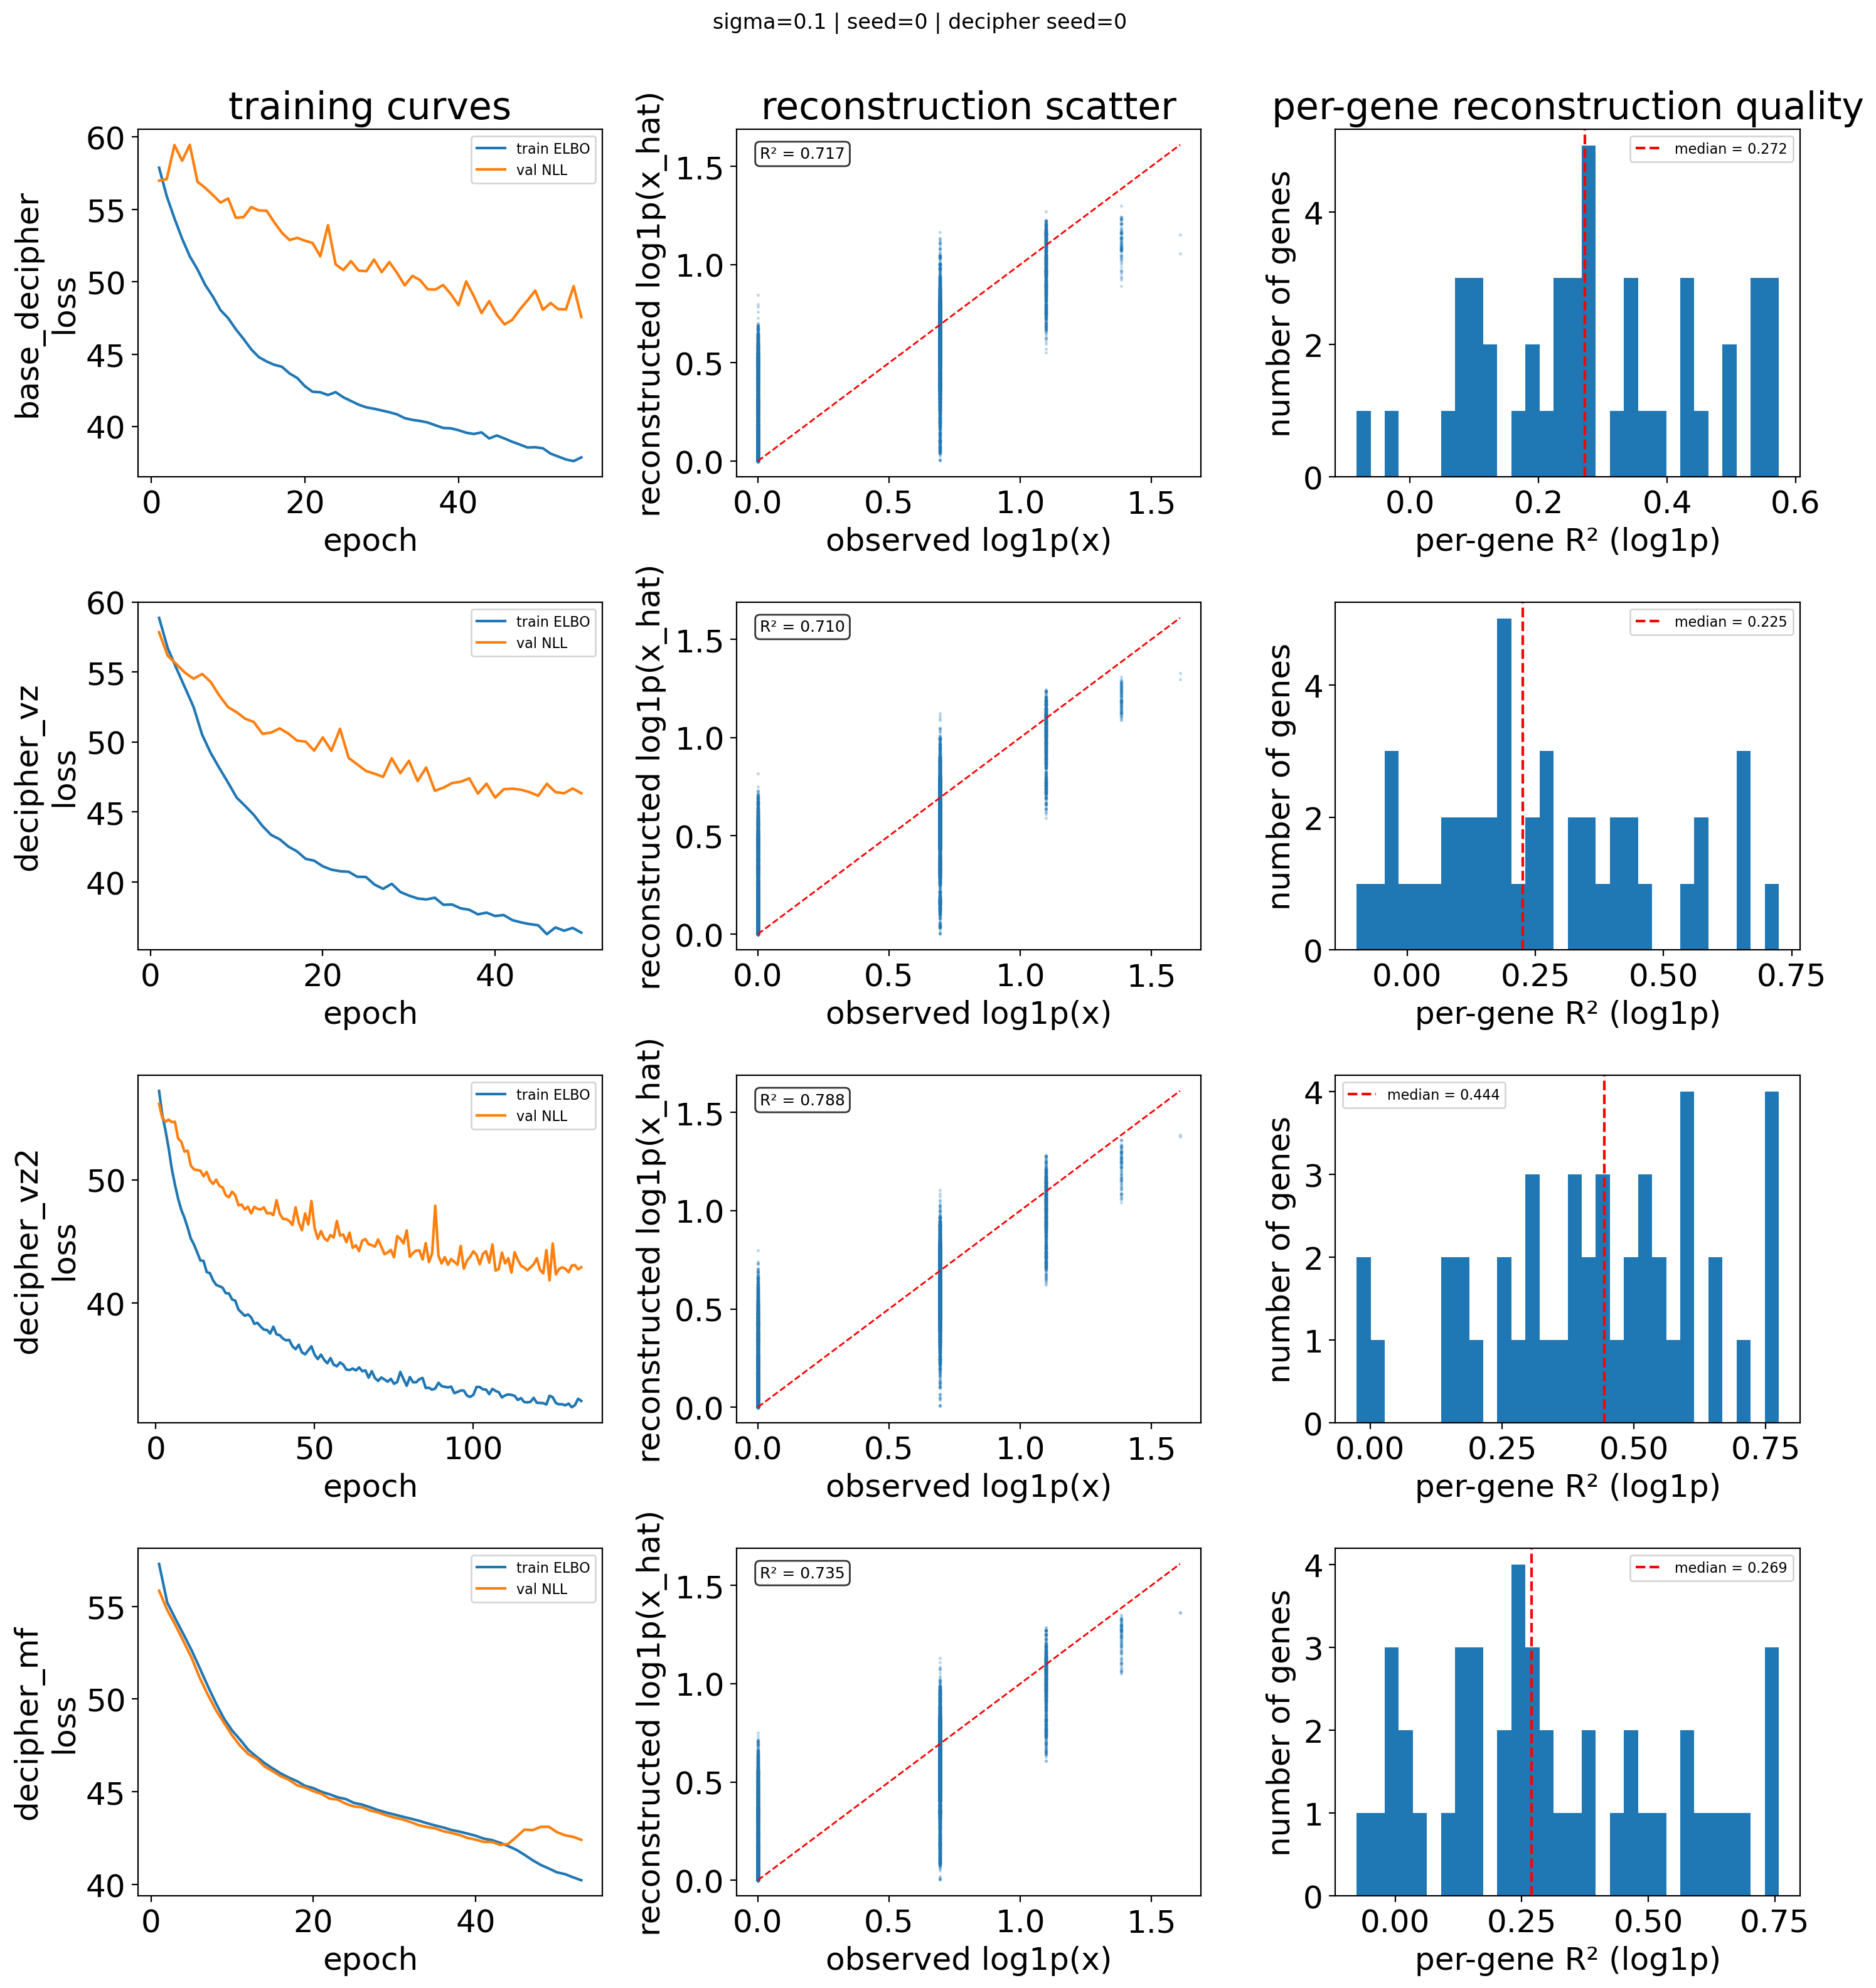

In [18]:
fig, summary_df, trained = my_reconstruction_all_models(
    date="0804",
    shift_sigma=0.1,
    seed=0,
    decipher_seed=0,
)
print(summary_df)
fig

Epoch 245 (batch 23/23) | | train elbo: 163.42 (last epoch: 163.47) | val ll: 169.72:  24%|██▍       | 245/1000 [04:06<12:39,  1.01s/it]2026-08-04 01:02:43,788 | INFO : Early stopping has been triggered.
2026-08-04 01:02:43,805 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-08-04 01:02:43,807 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-08-04 01:02:43,809 | INFO : Saving decipher model with run_id 2026-08-04-01-02-43-asymptotic-chocolate-waffle.


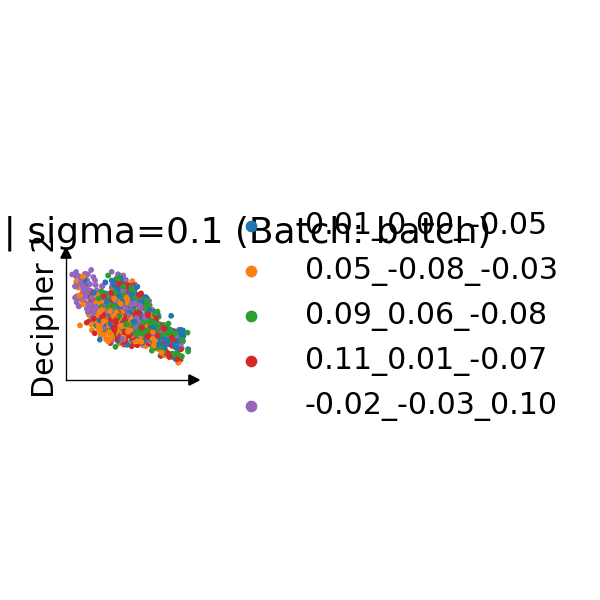

   date  shift_sigma  seed  decipher_seed      model_tag  r2_overall  \
0  0804          0.1     0              0  base_decipher    0.759013   
1  0804          0.1     0              0    decipher_vz    0.747965   
2  0804          0.1     0              0   decipher_vz2    0.759006   
3  0804          0.1     0              0    decipher_mf    0.765911   

   r2_per_gene_median  
0            0.456437  
1            0.434940  
2            0.451031  
3            0.473845  


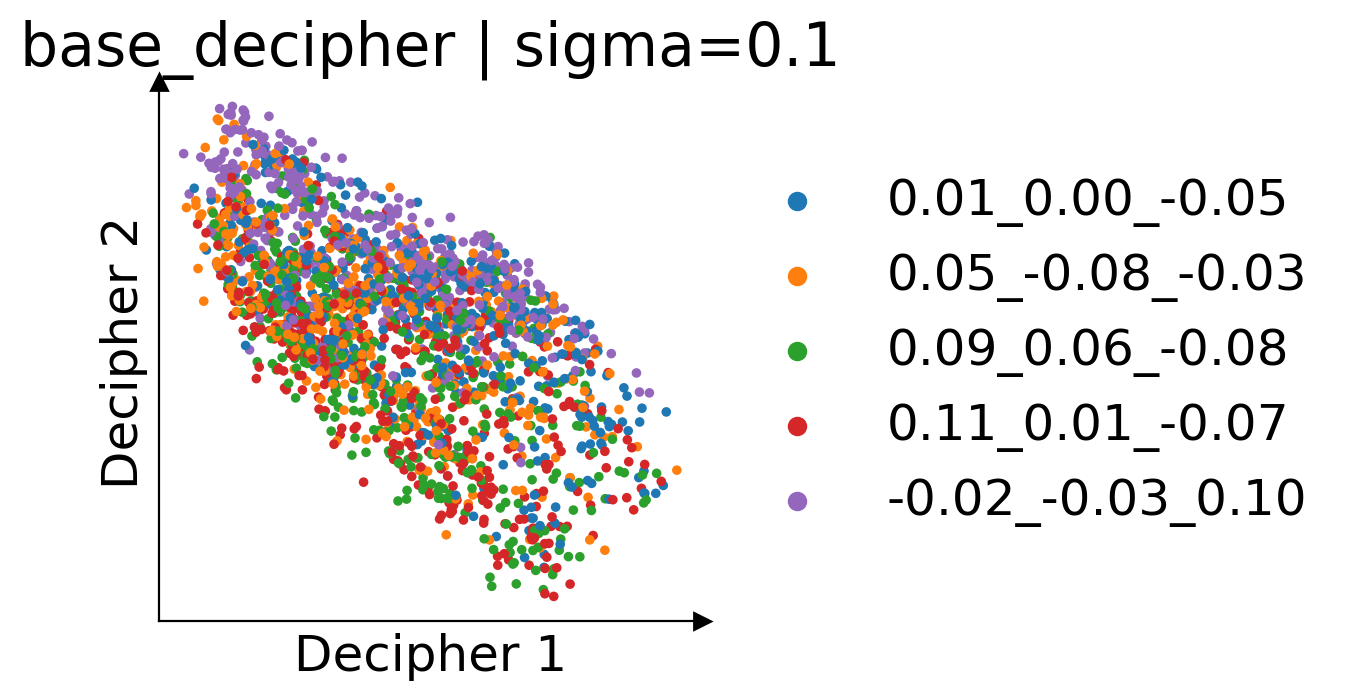

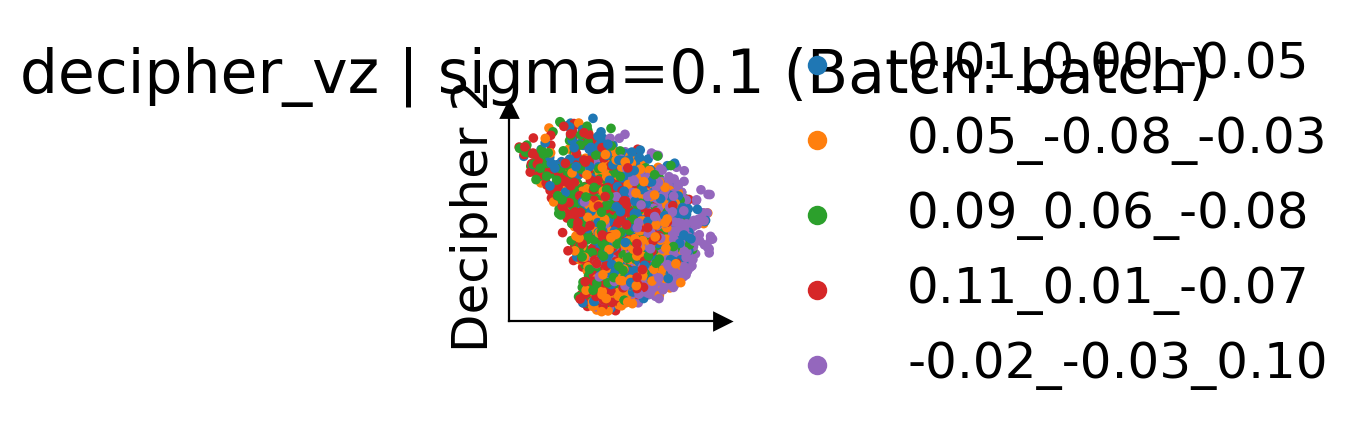

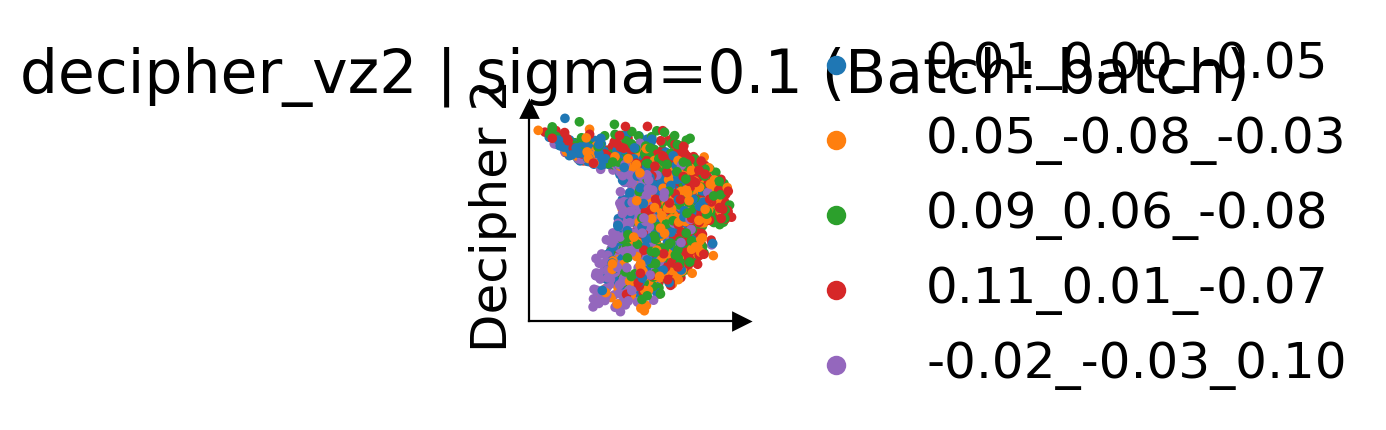

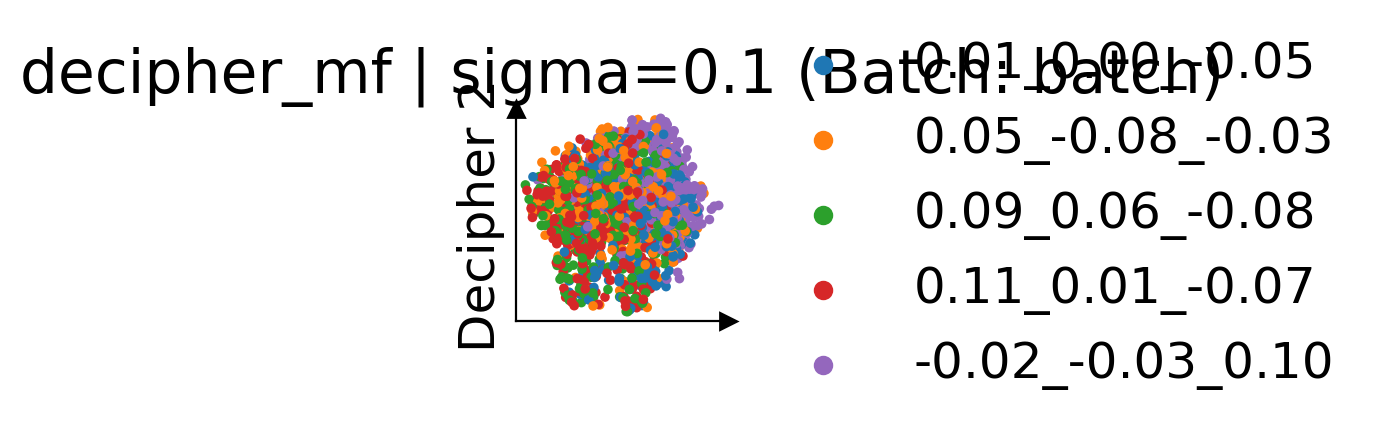

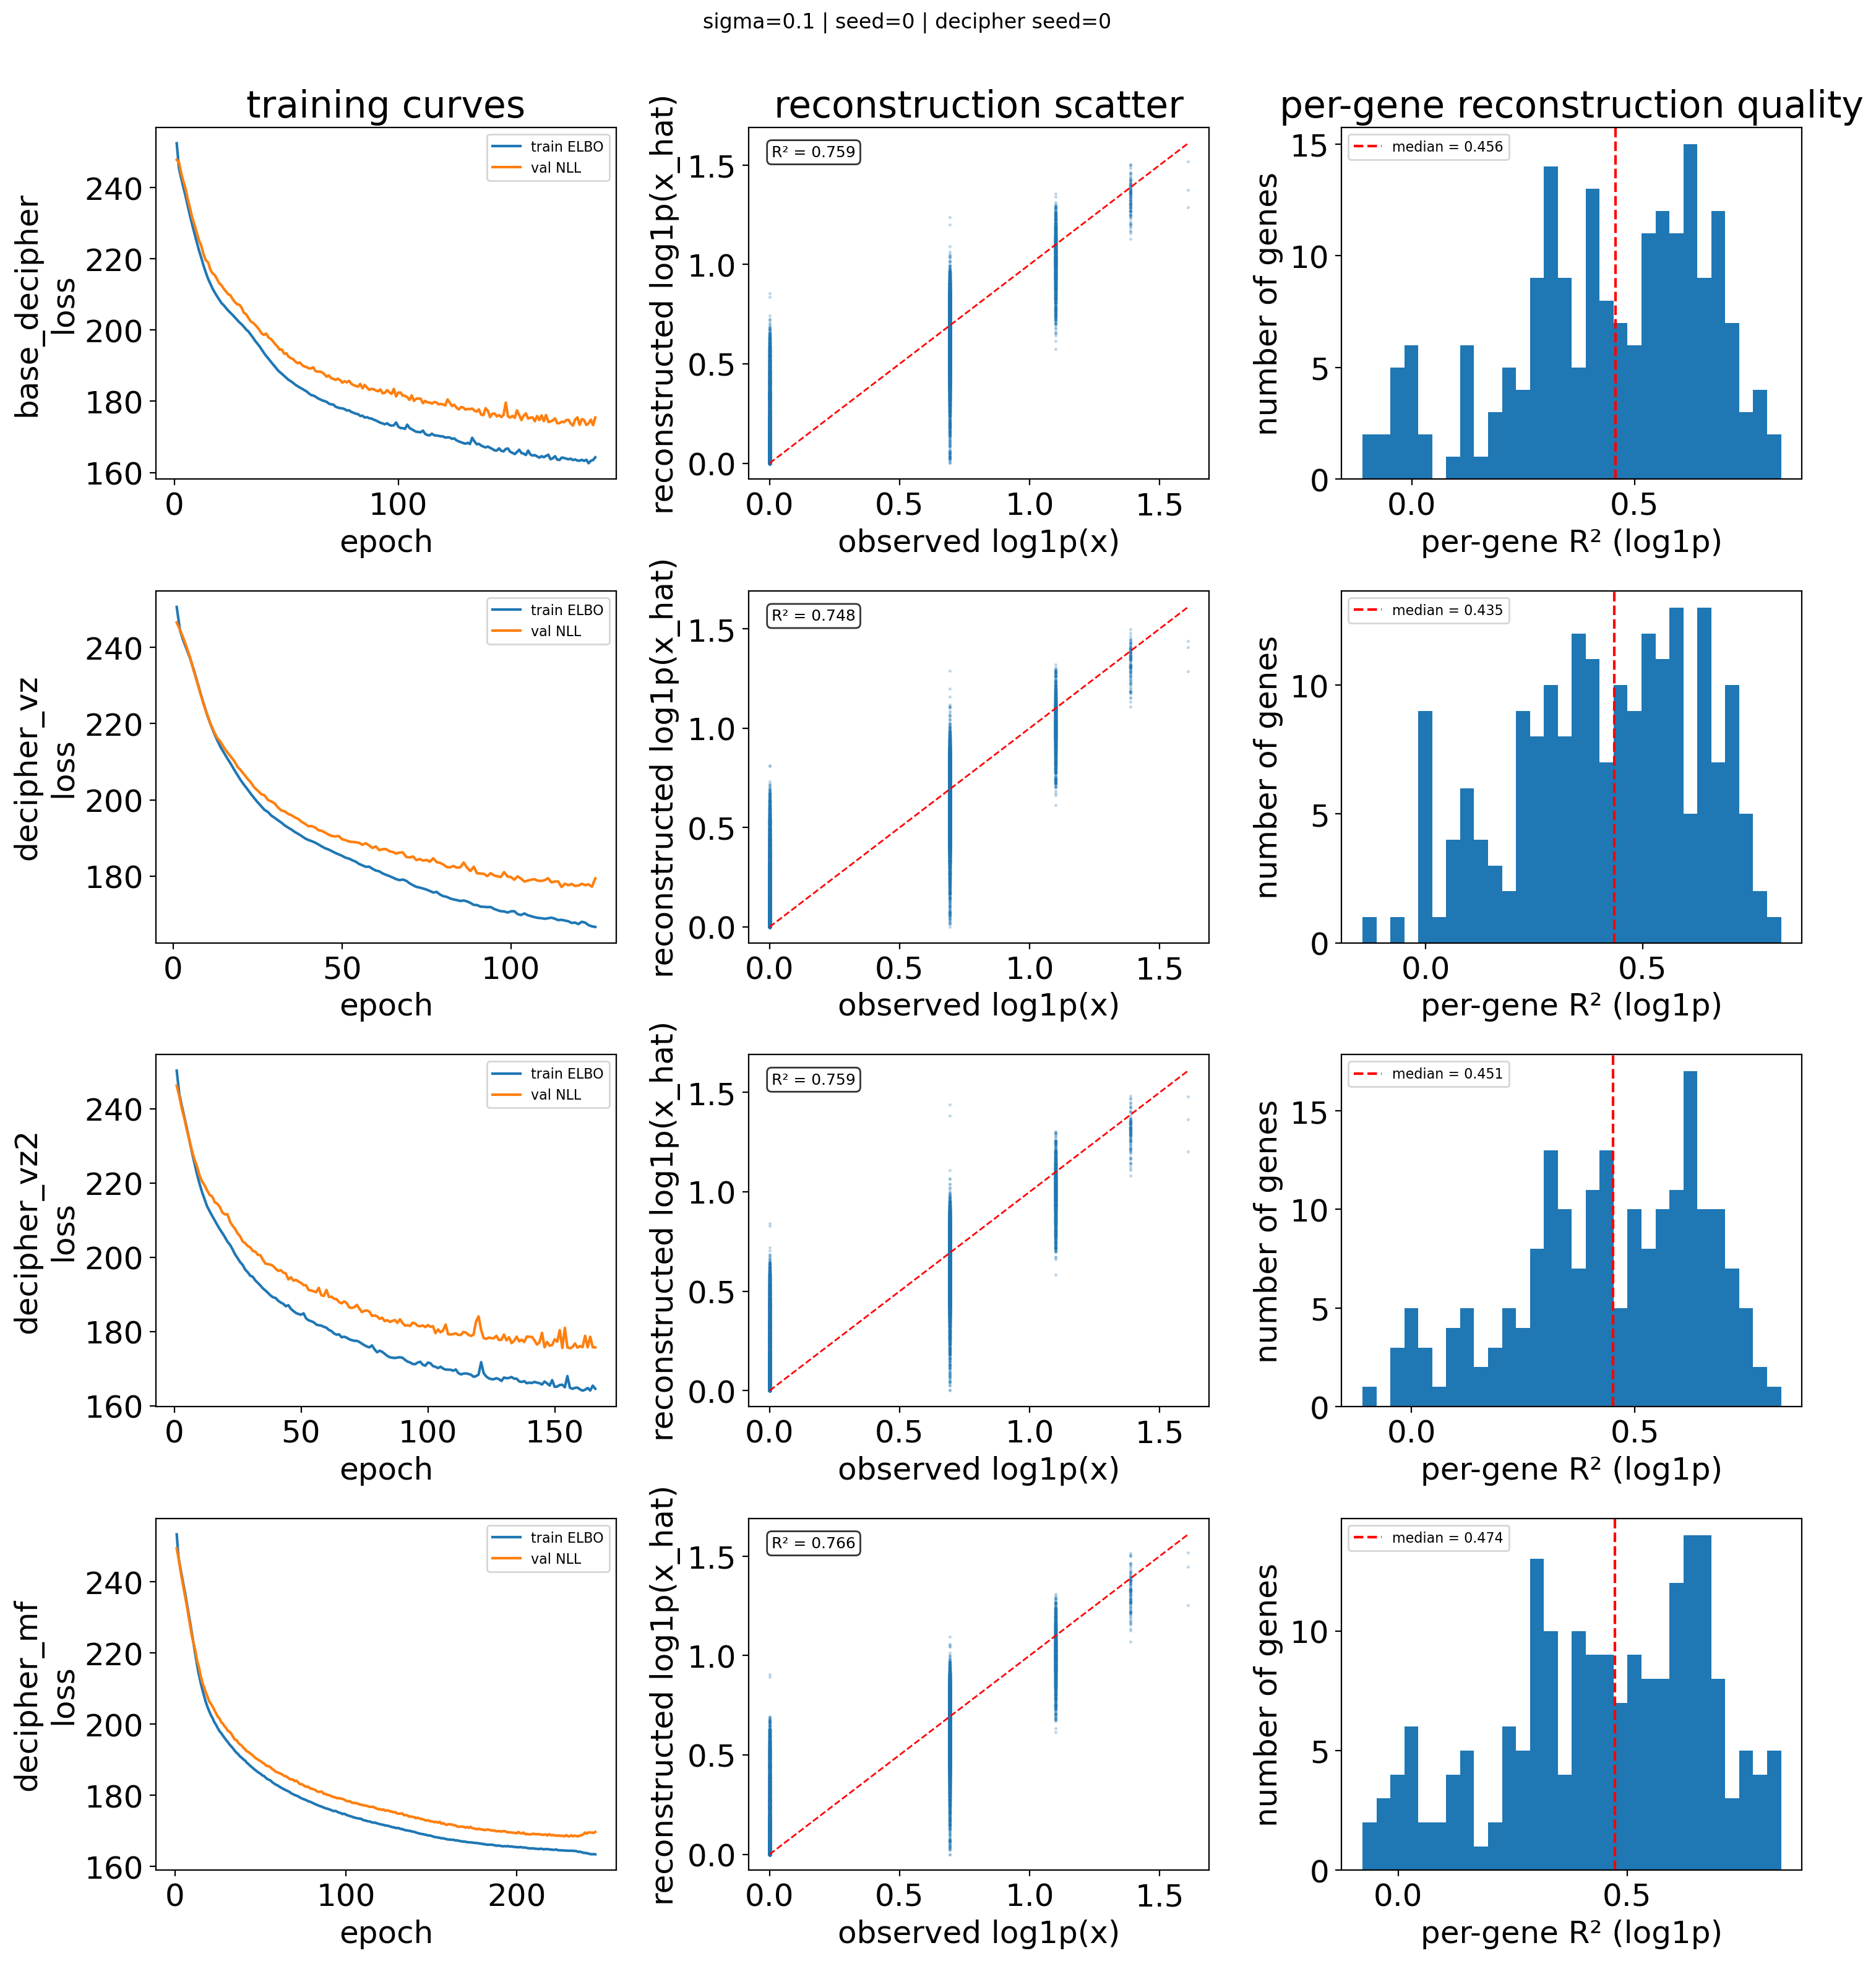

In [21]:
fig, summary_df, trained = my_reconstruction_all_models(
    date="0804",
    shift_sigma=0.1,
    seed=0,
    n_samples=500, n_genes=200, 
    decipher_seed=0,
)
print(summary_df)

In [ ]:
import os

In [22]:
sweep_log = pd.read_csv(
    "../Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0804/sweep_log_[0.1, 0.2, 0.3, 0.4, 0.5]_[0, 1, 2].csv")
sweep_log.head()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0804/sweep_log_[0.1, 0.2, 0.3, 0.4, 0.5]_[0, 1, 2].csv'